### Import Library

In [1]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
# #
# import scipy as stats

import warnings

### Set option in pandas to display all rows and columns in dataset

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows", None)

### Ignore library Deprecated warning messages

In [3]:
def ignore_warning(): # define function 
    return warnings.filterwarnings(action='ignore', category= DeprecationWarning, module=r'.*randpool')

ignore_warning() # function call

### Load Dataset

In [4]:
def load_dataset(dataset_url): # define function
    return  pd.read_csv(dataset_url) # to read csv data
 
# call function load_dataset() and store dataset value in population_dataframe
population_dataframe = load_dataset('PEA04.20231018T191000.csv')

# EDA (Exploratory Data Analysis)

In [5]:
# Dimensions of dataset
population_dataframe.shape

(6669, 7)

In [6]:
# Gives top 5 rows of dataset
population_dataframe.head(30)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0
5,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-West,Thousand,50.1
6,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Dublin,Thousand,93.3
7,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-East,Thousand,58.5
8,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Midland,Thousand,23.9
9,Estimated Population (Persons in April),2011,0 - 4 years,Male,State,Thousand,182.0


In [7]:
# Gives bottom 5 rows of dataset
population_dataframe.tail(100)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
6569,Estimated Population (Persons in April),2023,75 - 79 years,Both sexes,Midland,Thousand,9.7
6570,Estimated Population (Persons in April),2023,75 - 79 years,Male,State,Thousand,77.8
6571,Estimated Population (Persons in April),2023,75 - 79 years,Male,Border,Thousand,7.4
6572,Estimated Population (Persons in April),2023,75 - 79 years,Male,West,Thousand,8.4
6573,Estimated Population (Persons in April),2023,75 - 79 years,Male,Mid-West,Thousand,8.5
6574,Estimated Population (Persons in April),2023,75 - 79 years,Male,South-East,Thousand,7.7
6575,Estimated Population (Persons in April),2023,75 - 79 years,Male,South-West,Thousand,12.2
6576,Estimated Population (Persons in April),2023,75 - 79 years,Male,Dublin,Thousand,18.3
6577,Estimated Population (Persons in April),2023,75 - 79 years,Male,Mid-East,Thousand,10.5
6578,Estimated Population (Persons in April),2023,75 - 79 years,Male,Midland,Thousand,4.7


In [8]:
# Gives random sample data

population_dataframe.sample(10)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
4307,Estimated Population (Persons in April),2019,35 - 39 years,Male,South-West,Thousand,26.8
1198,Estimated Population (Persons in April),2013,30 - 34 years,Male,Border,Thousand,14.3
4555,Estimated Population (Persons in April),2019,80 - 84 years,Female,Border,Thousand,4.4
329,Estimated Population (Persons in April),2011,60 - 64 years,Both sexes,South-West,Thousand,33.0
683,Estimated Population (Persons in April),2012,30 - 34 years,Both sexes,Midland,Thousand,23.4
2112,Estimated Population (Persons in April),2015,10 - 14 years,Both sexes,Dublin,Thousand,76.5
805,Estimated Population (Persons in April),2012,50 - 54 years,Female,South-East,Thousand,12.9
1964,Estimated Population (Persons in April),2014,75 - 79 years,Female,West,Thousand,5.8
2727,Estimated Population (Persons in April),2016,30 - 34 years,Both sexes,State,Thousand,360.3
261,Estimated Population (Persons in April),2011,45 - 49 years,Female,State,Thousand,152.9


In [9]:
# rename columns name i.e no space should be in columns name
# use of try and except to handle if value list has not appropriate length for column
new_column_name = ['statistic_label','year','age_group','sex','region','unit','value']

def columns_dict(cols):
    new_col = {}
    
    if len(cols) == len(population_dataframe.columns):
        try:
            for i in range(len(cols)):
                new_col[population_dataframe.columns[i]] = cols[i]
        except:
            print("An error occurred while creating the column dictionary.")
    else:
        print(f"Your length of Population Dataframe {len(population_dataframe.columns)} != {len(new_column_name)} with length of New Column ")
    
    return new_col

col_dict = columns_dict(new_column_name)


### Rename Column names

In [10]:

# inplace = True set the values permenantly so that we can use new columns name
population_dataframe.rename(columns=col_dict, inplace=True)

In [11]:
# drop column STATISTIC Label and Unit because it
population_dataframe.drop({'statistic_label', 'unit'}, axis=1, inplace=True)
population_dataframe.head()

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0


In [12]:
# Checking the types of data
population_dataframe.dtypes

year           int64
age_group     object
sex           object
region        object
value        float64
dtype: object

In [13]:
# isna().sum() provide sum of null value in each column in datasets
population_dataframe.isnull().sum()

year         0
age_group    0
sex          0
region       0
value        0
dtype: int64

In [14]:
# info() provide information about datasets
population_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       6669 non-null   int64  
 1   age_group  6669 non-null   object 
 2   sex        6669 non-null   object 
 3   region     6669 non-null   object 
 4   value      6669 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 260.6+ KB


In [15]:
population_dataframe.count()

year         6669
age_group    6669
sex          6669
region       6669
value        6669
dtype: int64

In [16]:
# count duplicated value in dataset
population_dataframe.duplicated().sum()

0

In [17]:
# describe() generate statistical descriptive value of dataset
population_dataframe.describe()

,year,value
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


In [18]:
# describe(include=object) generate statistical descriptive value for object datatype of dataset
population_dataframe.describe(include=object)

,age_group,sex,region
count,6669,6669,6669
unique,19,3,9
top,0 - 4 years,Both sexes,State
freq,351,2223,741


In [19]:
# It return all unique value of series object
population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

In [20]:
# It return all unique value of series object
population_dataframe['year'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

#### Remove State from observation

In [21]:
# Remove State observation from region because state is sum of all other 8 region population

new_population_dataframe = population_dataframe.loc[population_dataframe['region'] != 'State']
new_population_dataframe.head()

,year,age_group,sex,region,value
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0
5,2011,0 - 4 years,Both sexes,South-West,50.1


In [22]:
# Unique region 
new_population_dataframe['region'].unique()

array(['Border', 'West', 'Mid-West', 'South-East', 'South-West', 'Dublin',
       'Mid-East', 'Midland'], dtype=object)

In [23]:
# Unique sex 
new_population_dataframe['sex'].unique()

array(['Both sexes', 'Male', 'Female'], dtype=object)

In [24]:
# Unique age_group
new_population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

#### Remove Both sexes and All age group from observation

In [25]:
# Remove Both sexes observation from sex column and All ages observation from age_group column because both sexes is sum of male and female population and all ages are sum of rest of categorical age

new_population_dataframe = new_population_dataframe.loc[(new_population_dataframe['sex'] != 'Both sexes') & (new_population_dataframe['age_group'] != 'All ages')]
new_population_dataframe.reset_index(drop=True, inplace=True)
new_population_dataframe.tail(5)

,year,age_group,sex,region,value
3739,2023,85 years and over,Female,South-East,5.0
3740,2023,85 years and over,Female,South-West,8.1
3741,2023,85 years and over,Female,Dublin,15.5
3742,2023,85 years and over,Female,Mid-East,6.0
3743,2023,85 years and over,Female,Midland,3.0


In [26]:
new_population_dataframe.shape

(3744, 5)

In [27]:
# Boxplot helps to identify outliers
def plot_boxplot(col_name):
    plt.figure(figsize=(8,6))
    plt.boxplot(x=col_name);

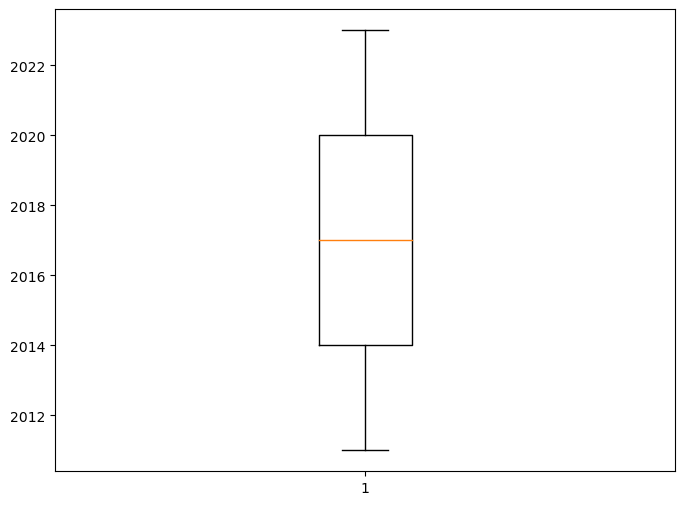

In [28]:
# call plot_boxplot for year column, Hence there are no outliers
plot_boxplot(new_population_dataframe['year'])

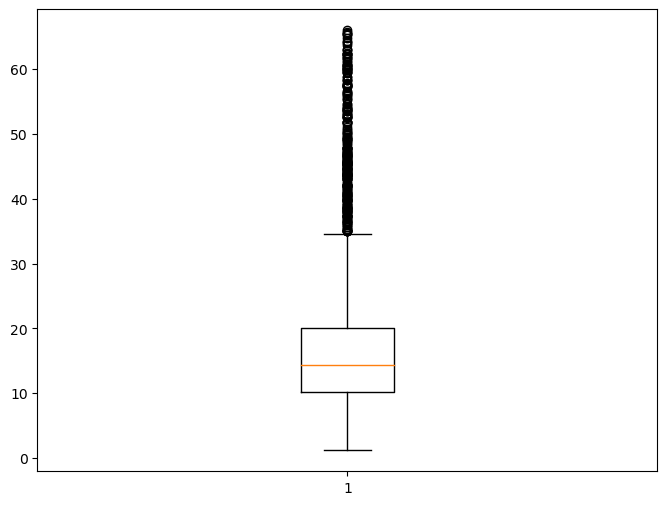

In [29]:
# call plot_boxplot function for value column, Hence there are outliers
plot_boxplot(new_population_dataframe['value'])

IQR 9.8
lower_limit -4.500000000000002
upper_limit 34.7


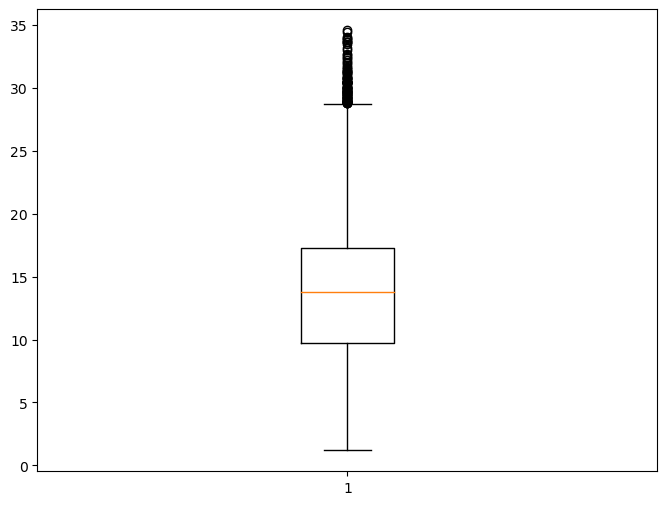

In [30]:
# Function to remove outliers from datasets by using IQR (Interquartile Range)

def remove_outliers(col_name):
    Q1 = new_population_dataframe[col_name].quantile(0.25)
    Q3 = new_population_dataframe[col_name].quantile(0.75)
    IQR = Q3-Q1 
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR
    print('IQR',IQR)
    print('lower_limit',lower_limit)
    print('upper_limit',upper_limit)
    new_data = new_population_dataframe[(new_population_dataframe['value'] > lower_limit) & (new_population_dataframe['value'] < upper_limit)]
    return new_data
    
newdata_no_outliers = remove_outliers('value')

plot_boxplot(newdata_no_outliers['value'])


In [31]:
# plt.figure(figsize=(8,6))
# # correlation = population_dataframe.corr()
# correlation = newdata_no_outliers.corr(numeric_only=True)
# plt.heatmap(correlation, annot=True, fmt='.2f', linewidths=2, cmap="BrBG")
# correlation


In [32]:
newdata_no_outliers.describe()

,year,value
count,3441.000000,3441.000000
mean,2016.977332,14.151148
std,3.742366,6.793485
min,2011.000000,1.200000
25%,2014.000000,9.700000
50%,2017.000000,13.800000
75%,2020.000000,17.300000
max,2023.000000,34.600000


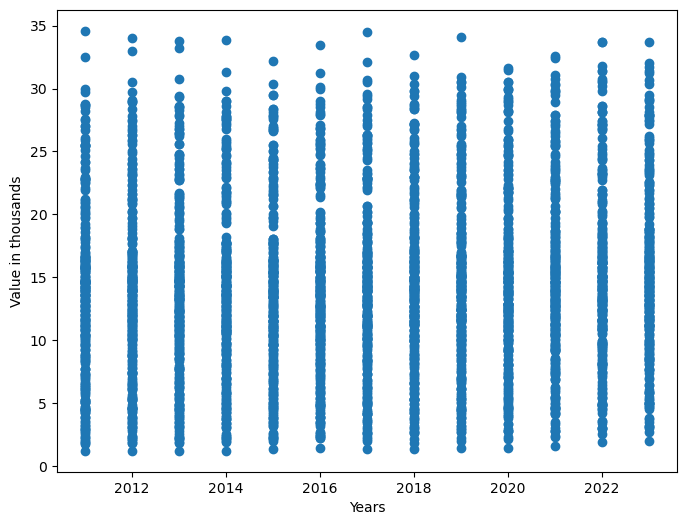

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(newdata_no_outliers["year"], newdata_no_outliers["value"])
# ax.scatter(population_dataframe["year"], population_dataframe["value"])

ax.set_xlabel("Years")
ax.set_ylabel("Value in thousands")
plt.show()

In [34]:
newdata_no_outliers.describe()

,year,value
count,3441.000000,3441.000000
mean,2016.977332,14.151148
std,3.742366,6.793485
min,2011.000000,1.200000
25%,2014.000000,9.700000
50%,2017.000000,13.800000
75%,2020.000000,17.300000
max,2023.000000,34.600000


In [35]:
# Histplot explain distribution of data i.e Symmetric distribution  data
# plt.histplot(data=newdata_no_outliers, x='value', kde=True, bins=50);

#### Calculate Skewness for distribution of data

In [36]:
# best skew value should be -3 to +3
# skew_value = stats.skew(newdata_no_outliers['value'], axis=0, bias=True)
# print('Skew Value',skew_value)

#### Calculate kurtosis for distribution of data

In [37]:
# # best kurtosis value should be -10 to +10
# kurtosis_value = stats.kurtosis(newdata_no_outliers['value'], axis=0, bias=True)
# print('kurtosis Value',kurtosis_value)

In [38]:
newdata_no_outliers.describe(include=object)

,age_group,sex,region
count,3441,3441,3441
unique,18,2,8
top,85 years and over,Male,Border
freq,208,1723,468


In [39]:
newdata_no_outliers['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over'], dtype=object)

### Total population by year of all states from 2011-2023

In [40]:

all_age_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == 'All ages')].reset_index(drop=True)


In [41]:
# Statistical value for bar graph year and population
all_age_bt_sex_state_df[['year','value']]

,year,value
0,2011,4574.9
1,2012,4593.7
2,2013,4614.7
3,2014,4645.4
4,2015,4687.8
5,2016,4739.6
6,2017,4810.9
7,2018,4884.9
8,2019,4958.5
9,2020,5029.9


#### Statistical value  for bar graph

In [42]:
print(f"Max: {all_age_bt_sex_state_df[['year','value']].max()},  Min: {all_age_bt_sex_state_df[['year','value']].min()}, Mean: {all_age_bt_sex_state_df[['year','value']].mean()} ")


Max: year     2023.0
value    5281.6
dtype: float64,  Min: year     2011.0
value    4574.9
dtype: float64, Mean: year     2017.000000
value    4852.353846
dtype: float64 


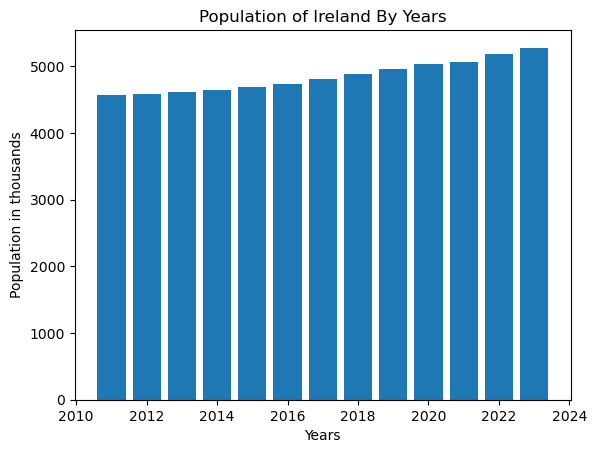

In [43]:
#Bar graph to compare population by year 2011-2023 
plt.bar(all_age_bt_sex_state_df['year'], all_age_bt_sex_state_df['value'])
plt.title("Population of Ireland By Years")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

### Child population age 0-4 years, both sex, all states

In [44]:

age04_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '0 - 4 years')].reset_index(drop=True)
age04_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2012,0 - 4 years,Both sexes,State,358.2
2,2013,0 - 4 years,Both sexes,State,353.0
3,2014,0 - 4 years,Both sexes,State,345.4
4,2015,0 - 4 years,Both sexes,State,337.9
5,2016,0 - 4 years,Both sexes,State,331.4
6,2017,0 - 4 years,Both sexes,State,325.0
7,2018,0 - 4 years,Both sexes,State,320.0
8,2019,0 - 4 years,Both sexes,State,315.0
9,2020,0 - 4 years,Both sexes,State,308.7


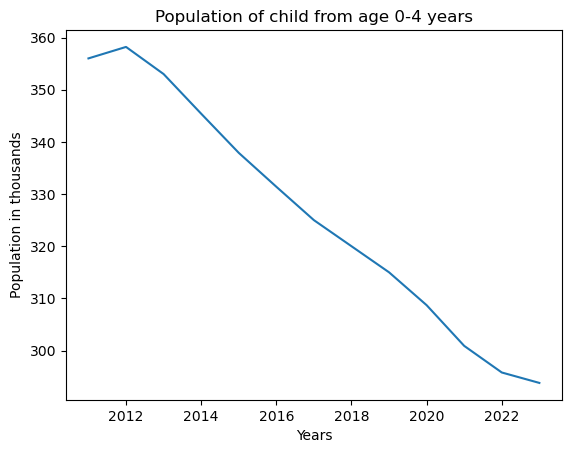

In [45]:
#Bar graph to compare population by year 2011-2023 
plt.plot(age04_bt_sex_state_df['year'], age04_bt_sex_state_df['value'])
plt.title("Population of child from age 0-4 years")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

# why child birth is decreasing each year -> research

###  Older Adults Population age 85 years and above , both sex, all states

In [46]:
age85_above_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '85 years and over')].reset_index(drop=True)
age85_above_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,85 years and over,Both sexes,State,58.2
1,2012,85 years and over,Both sexes,State,59.8
2,2013,85 years and over,Both sexes,State,60.7
3,2014,85 years and over,Both sexes,State,62.7
4,2015,85 years and over,Both sexes,State,64.9
5,2016,85 years and over,Both sexes,State,67.3
6,2017,85 years and over,Both sexes,State,69.1
7,2018,85 years and over,Both sexes,State,71.8
8,2019,85 years and over,Both sexes,State,74.1
9,2020,85 years and over,Both sexes,State,75.6


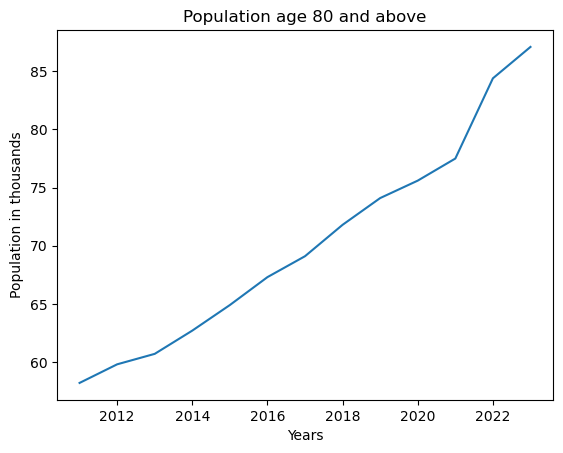

In [47]:
#Bar graph to compare population by year 2011-2023 
plt.plot(age85_above_bt_sex_state_df['year'], age85_above_bt_sex_state_df['value'])
plt.title("Population age 80 and above")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

#### Working population in ireland age 15-64

In [48]:
age_group_only= population_dataframe['age_group'].unique()
age_group_working_pop = age_group_only[3:13]
filt = population_dataframe['age_group'].isin(age_group_working_pop)
rando = population_dataframe.loc[filt]
working_age_bt_sex_state_df = rando.loc[(rando['sex'] == 'Both sexes') & (rando['region'] == 'State')].reset_index(drop=True)
working_age_bt_sex_state_df
### is total population between age group 15 - 64 from year 2011 to 2023

,year,age_group,sex,region,value
0,2011,15 - 19 years,Both sexes,State,281.0
1,2011,20 - 24 years,Both sexes,State,298.6
2,2011,25 - 29 years,Both sexes,State,362.9
3,2011,30 - 34 years,Both sexes,State,393.4
4,2011,35 - 39 years,Both sexes,State,363.1
5,2011,40 - 44 years,Both sexes,State,329.3
6,2011,45 - 49 years,Both sexes,State,304.1
7,2011,50 - 54 years,Both sexes,State,273.7
8,2011,55 - 59 years,Both sexes,State,243.4
9,2011,60 - 64 years,Both sexes,State,217.1


In [49]:
working_age_grp = working_age_bt_sex_state_df.groupby(['year']).sum().reset_index()
working_age_grp

/var/folders/8h/zngsh8g53bn5q_0swnh41t5r0000gn/T/ipykernel_54971/3217115053.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  working_age_grp = working_age_bt_sex_state_df.groupby(['year']).sum().reset_index()


,year,value
0,2011,3066.6
1,2012,3055.7
2,2013,3051.5
3,2014,3058.5
4,2015,3075.9
5,2016,3104.3
6,2017,3148.1
7,2018,3194.0
8,2019,3241.6
9,2020,3290.1


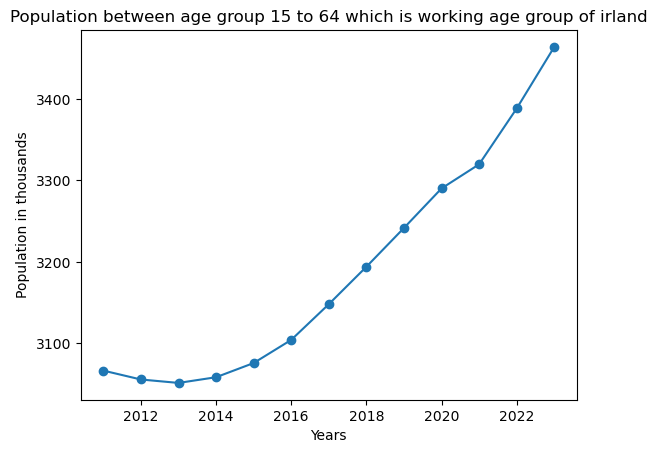

In [50]:
plt.plot(working_age_grp['year'], working_age_grp['value'], marker='o')
plt.title("Population between age group 15 to 64 which is working age group of irland")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

In [51]:
#childrean age group

age_group_child= age_group_only[0:2]
filt = population_dataframe['age_group'].isin(age_group_child)
child_pop = population_dataframe.loc[filt].reset_index(drop=True)
child_pop = child_pop.loc[(child_pop['sex'] == 'Both sexes') & (child_pop['region'] == 'State')]
child_pop = child_pop.groupby('year').sum().reset_index()

/var/folders/8h/zngsh8g53bn5q_0swnh41t5r0000gn/T/ipykernel_54971/438374832.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  child_pop = child_pop.groupby('year').sum().reset_index()


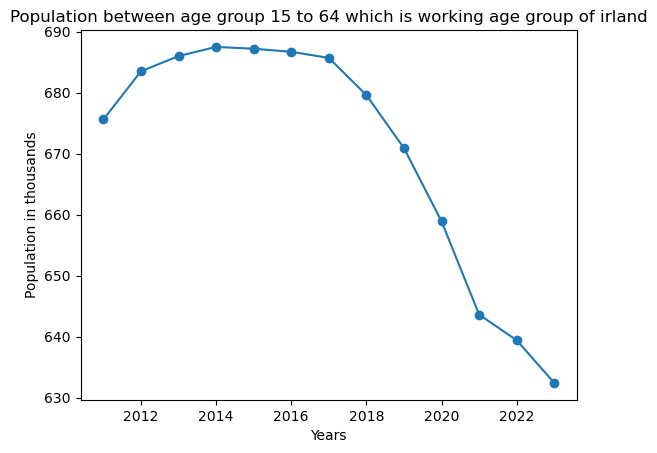

In [52]:
plt.plot(child_pop['year'], child_pop['value'], marker='o')
plt.title("Population between age group 15 to 64 which is working age group of irland")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

In [53]:
age_group_ealder= age_group_only[13:]
filt = population_dataframe['age_group'].isin(age_group_ealder)
ealder_pop = population_dataframe.loc[filt].reset_index(drop=True)
ealder_pop = ealder_pop.loc[(ealder_pop['sex'] == 'Both sexes') & (ealder_pop['region'] == 'State')]
ealder_pop = ealder_pop.groupby('year').sum().reset_index()

/var/folders/8h/zngsh8g53bn5q_0swnh41t5r0000gn/T/ipykernel_54971/4176524436.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ealder_pop = ealder_pop.groupby('year').sum().reset_index()


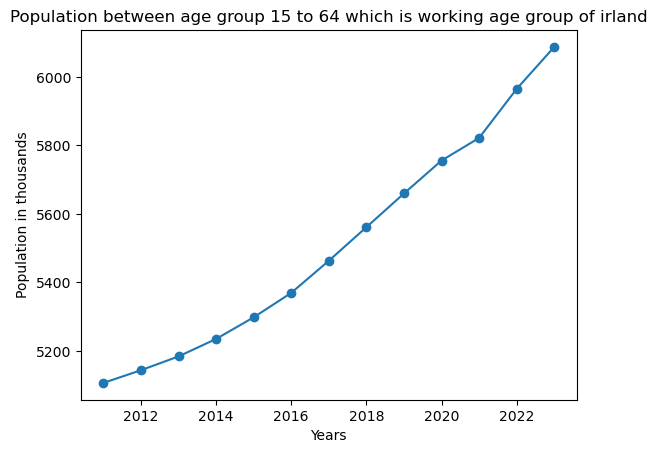

In [54]:
plt.plot(ealder_pop['year'], ealder_pop['value'], marker='o')
plt.title("Population between age group 15 to 64 which is working age group of irland")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

In [55]:
data_frame= [child_pop,ealder_pop, working_age_grp]
data_frame = pd.concat([child_pop['year'], child_pop['value'],ealder_pop['value'], working_age_grp['value']],keys= ['year', 'child', 'working', 'old'], axis=1).reset_index(drop=True)
data_frame

,year,child,working,old
0,2011,675.6,5106.5,3066.6
1,2012,683.5,5143.6,3055.7
2,2013,686.0,5183.9,3051.5
3,2014,687.5,5234.9,3058.5
4,2015,687.2,5298.1,3075.9
5,2016,686.7,5369.5,3104.3
6,2017,685.7,5463.3,3148.1
7,2018,679.6,5561.4,3194.0
8,2019,670.9,5659.8,3241.6
9,2020,658.9,5756.0,3290.1


In [56]:

# for i in range(0,len(data_frame), 1):
#     for_pie = (data_frame.iloc[i, 1], data_frame.iloc[i, 2], data_frame.iloc[i, 3])
#     years = data_frame.iloc[i,0]
#     plt.pie(for_pie, labels=['child', 'working', 'old'], shadow=True, startangle=90, autopct='%1.1f%%',  wedgeprops={'edgecolor': '#ffffff'} )
#     plt.title(f'ratio of the child to working people to old people in year {years}')
#     plt.tight_layout()
#     plt.show()
# newdata_no_outliers

In [57]:
filter_mf_df = newdata_no_outliers[(newdata_no_outliers['sex'] == 'Male') | (newdata_no_outliers['sex'] == 'Female')]
male_female_df = filter_mf_df.groupby(['year','region','sex'])['value'].sum()
male_female_df
    # = male_female_df.groupby(['year']).sum()

year  region      sex   
2011  Border      Female    195.0
                  Male      197.1
      Dublin      Female    140.3
                  Male      150.8
      Mid-East    Female    330.1
                  Male      327.3
      Mid-West    Female    233.0
                  Male      233.5
      Midland     Female    141.5
                  Male      142.5
      South-East  Female    205.4
                  Male      204.4
      South-West  Female    332.8
                  Male      329.6
      West        Female    220.3
                  Male      220.5
2012  Border      Female    194.6
                  Male      197.6
      Dublin      Female    177.7
                  Male      119.3
      Mid-East    Female    334.5
                  Male      330.3
      Mid-West    Female    234.9
                  Male      235.8
      Midland     Female    143.8
                  Male      143.5
      South-East  Female    206.4
                  Male      205.1
      South-West  Femal

In [58]:
class MaleFemalePopulationAnalysis:
    
    def __init__(self, population_dataframe, year, age_group = 'All ages'):
        self.population_dataframe = population_dataframe
        self.year = year
        self.age_group = age_group
        
        #filter male and female data based on year
        self.filter_year_d = (population_dataframe['year'] == self.year) & (population_dataframe['age_group'] == self.age_group) & (population_dataframe['sex'] != 'Both sexes') & (population_dataframe['region'] != 'State')
        self.filter_year_data = population_dataframe.loc[self.filter_year_d].reset_index()
        
        # Filter for Male data
        self.male_value = (self.filter_year_data[self.filter_year_data['sex'] == 'Male'])['value'].values

        # Filter for Female data
        self.female_value = (self.filter_year_data[self.filter_year_data['sex'] == 'Female'])['value'].values

        # Get all region
        self.all_region = self.filter_year_data['region'].unique()

        self.gender_dict = {
            'Male': np.array(self.male_value),
            'Female': np.array(self.female_value)
        }
        
    def get_male_female_stack_bar(self):

        total = []
        for i in range(len(self.male_value)):
            sums = self.male_value[i] + self.female_value[i]
            total.append(np.round(sums,2))

        bottom = np.zeros(len(self.all_region))

        fig, ax = plt.subplots(figsize=(12, 8))
        for key, value in self.gender_dict.items():
            bar_container = ax.bar(self.all_region, value, width=0.6, label=key, bottom=bottom)
            bottom += value
            ax.bar_label(bar_container, label_type='center', color='w',)
        ax.set_title(f"Male and Female Population of Irelnd  in each Region {self.year}")
        ax.legend(loc="upper right")
        plt.xlabel("States")
        plt.ylabel("Populations in Thousands")
        plt.show()
     
    def get_male_female_line_graph(self, marker_icon, title="Male and Female Population of Irelnd  in each Region"):
        
        plt.figure(figsize=(12,8))
        for key, value in self.gender_dict.items():
            plt.plot(self.all_region, value, label= key, marker=marker_icon)
            
        plt.title(f"{title} {self.year}")
        plt.legend()
        plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
        plt.xlabel("States")
        plt.ylabel("Populations in Thousands")
        plt.show()

        
# Initialize call MaleFemalePopulationAnalysis
# Data of 2011
male_female_pop_bar_2011 = MaleFemalePopulationAnalysis(population_dataframe, 2011)  
male_female_pop_line_2011 = MaleFemalePopulationAnalysis(population_dataframe, 2011)

# Data of 2023
male_female_pop_bar_2023 = MaleFemalePopulationAnalysis(population_dataframe, 2023)  
male_female_pop_line_2023 = MaleFemalePopulationAnalysis(population_dataframe, 2023)

# Data of Male and Female age 0-4 years
male_female_04_years = MaleFemalePopulationAnalysis(population_dataframe, 2023, age_group='0 - 4 years')


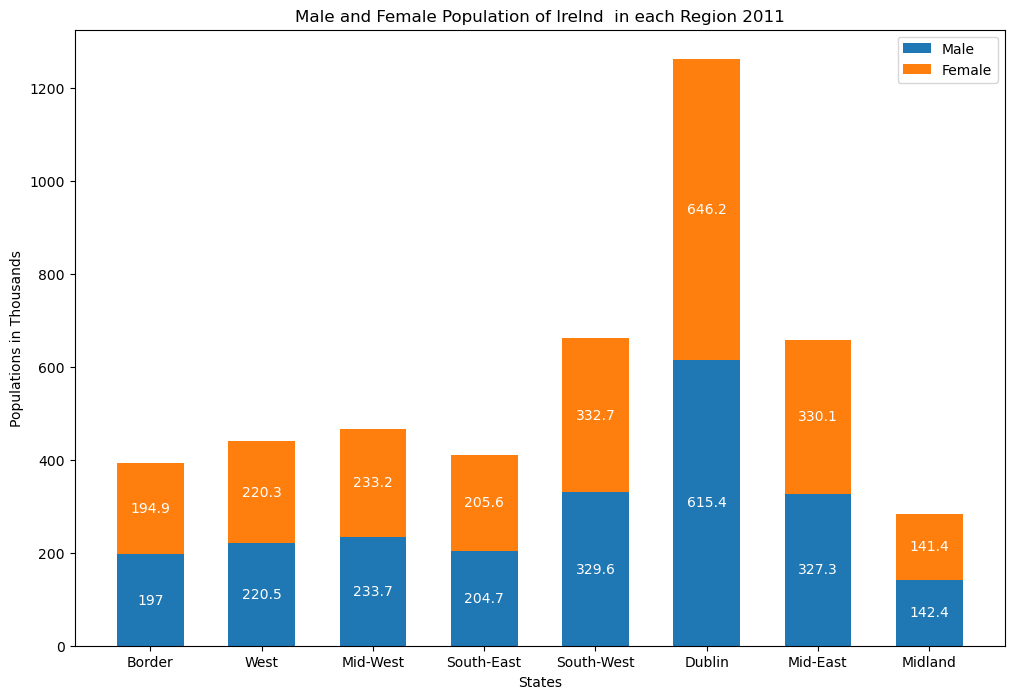

In [59]:
# Call method get_male_female_stack_bar() from class MaleFemalePopulationAnalysis
male_female_pop_bar_2011.get_male_female_stack_bar()

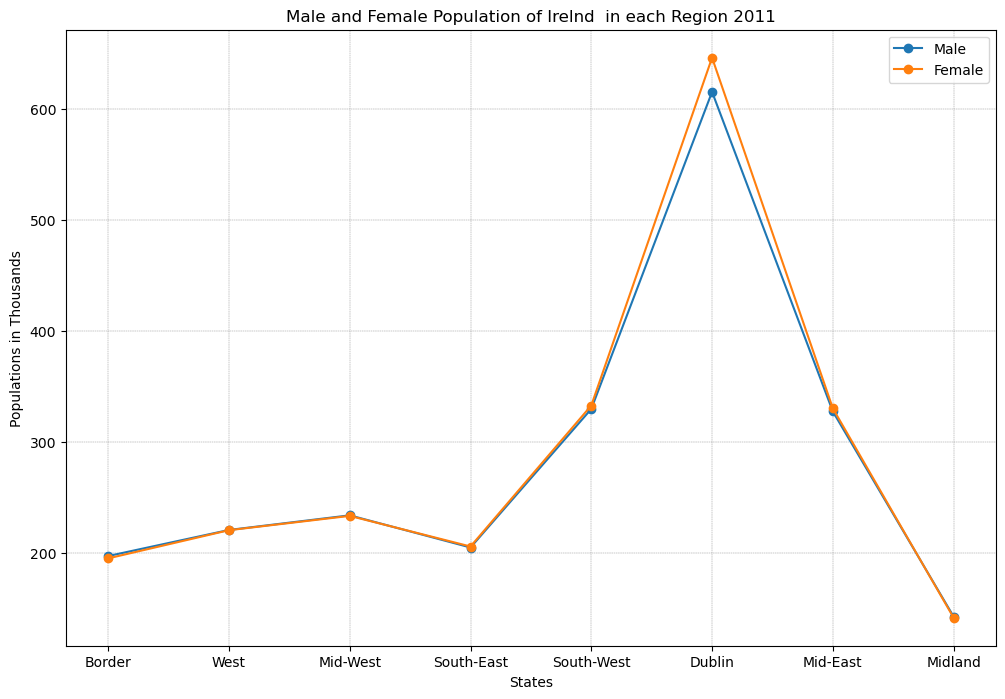

In [60]:
male_female_pop_line_2011.get_male_female_line_graph(marker_icon='o')

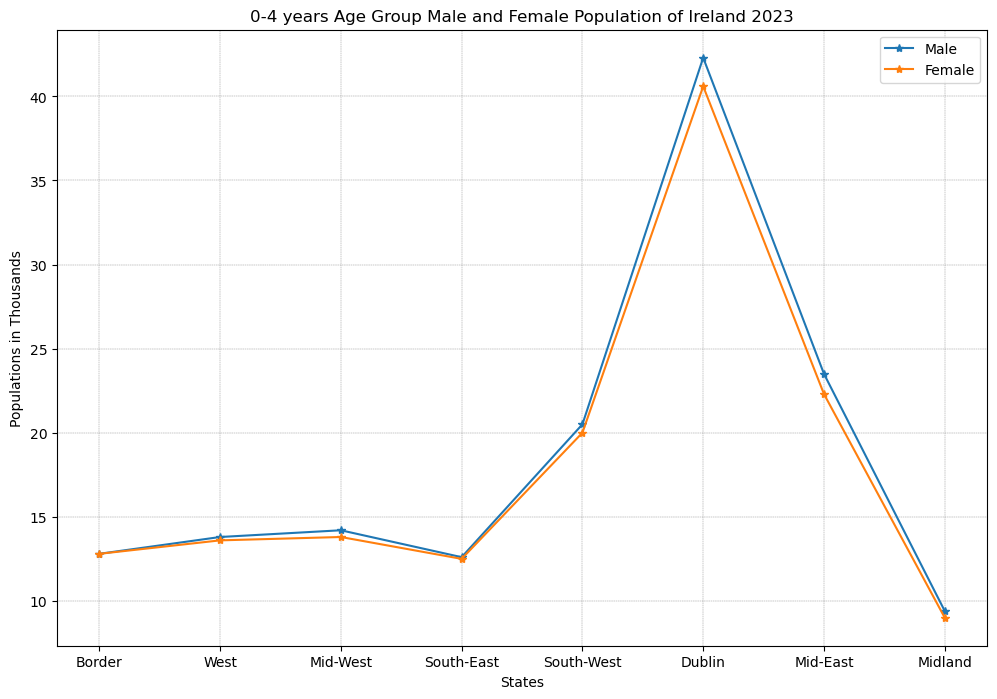

In [61]:
male_female_04_years.get_male_female_line_graph(title="0-4 years Age Group Male and Female Population of Ireland", marker_icon='*')

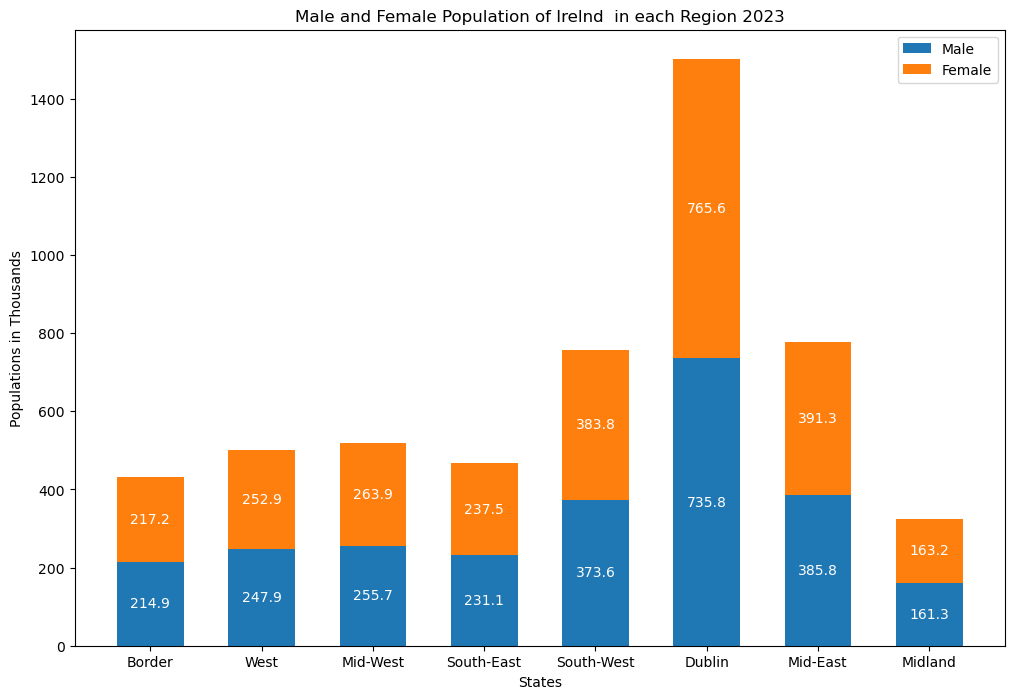

In [62]:
male_female_pop_bar_2023.get_male_female_stack_bar()

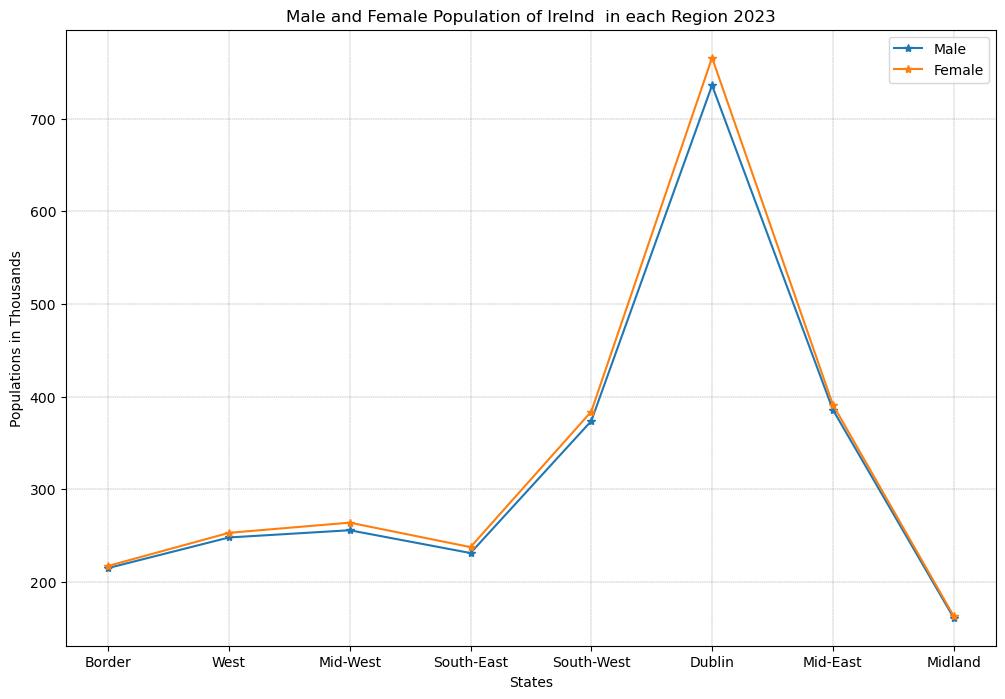

In [63]:
male_female_pop_line_2023.get_male_female_line_graph(marker_icon='*')